# Practical — Training Object Detectors on Aerial Wildlife Data

**Context:** In the previous practicals you used pre-trained models (MegaDetector,
SpeciesNet, DeepFaune). In the domain shift notebook you saw that MegaDetector
fails on aerial imagery. The solution? **Train your own detector.**

This notebook walks through two training approaches on the **Eikelboom** aerial
wildlife dataset (elephants, zebras, giraffes from Kenyan drone surveys):

| Approach | Model | Annotation type | Output |
|----------|-------|----------------|--------|
| **Part A** | YOLOv8 | Bounding boxes | Boxes + class labels |
| **Part B** | HerdNet (simplified) | Point annotations | Density heatmap + counts |

Both use the same tiled images (640x640 px), but different annotation formats:
- YOLO uses `class cx cy w h` (normalized bounding boxes)
- HerdNet uses `(x, y)` point annotations → FIDT density maps

**Goal:** Understand the training loop, not achieve state-of-the-art. We train
for just a few epochs to see the pipeline work end-to-end.

---

## Environment Setup

**Local (recommended):** use the `fit-training` conda environment:

```bash
conda env create -f environment-training.yml
conda activate fit-training
```

**Google Colab:** uncomment and run the cell below.

In [1]:
# Colab only — install dependencies if not already available
# import sys

# !git clone -b course_draft https://github.com/cwinkelmann/usde-innovations-applications-forest-it.git fit-course
# !cd fit-course && git pull
# !pip install -e "./fit-course[training,dev]"
#
# sys.path.append('./fit-course')

In [2]:
%matplotlib inline

from pathlib import Path
import json

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

DATA_DIR = Path("../data")
TILED_DIR = DATA_DIR / "eikelboom_tiled"
COCO_DIR = DATA_DIR / "eikelboom_coco"

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Tiled dataset: {TILED_DIR}")
print(f"COCO dataset:  {COCO_DIR}")

Device: mps
Tiled dataset: ../data/eikelboom_tiled
COCO dataset:  ../data/eikelboom_coco


## 1 — Explore the tiled training data

The original Eikelboom images (4603 x 3068 px) have been pre-tiled into
640 x 640 px tiles with overlap. Each tile has a matching YOLO-format label file.

In [3]:
train_imgs = sorted((TILED_DIR / "images" / "train").glob("*.jpg"))
val_imgs = sorted((TILED_DIR / "images" / "val").glob("*.jpg"))
train_labels = sorted((TILED_DIR / "labels" / "train").glob("*.txt"))
val_labels = sorted((TILED_DIR / "labels" / "val").glob("*.txt"))

print(f"Train: {len(train_imgs)} images, {len(train_labels)} labels")
print(f"Val:   {len(val_imgs)} images, {len(val_labels)} labels")

# Class mapping from dataset.yaml
CLASS_NAMES = {0: "Elephant", 1: "Giraffe", 2: "Zebra"}
CLASS_COLORS = {0: "#E74C3C", 1: "#F39C12", 2: "#3498DB"}

Train: 1057 images, 1057 labels
Val:   506 images, 506 labels


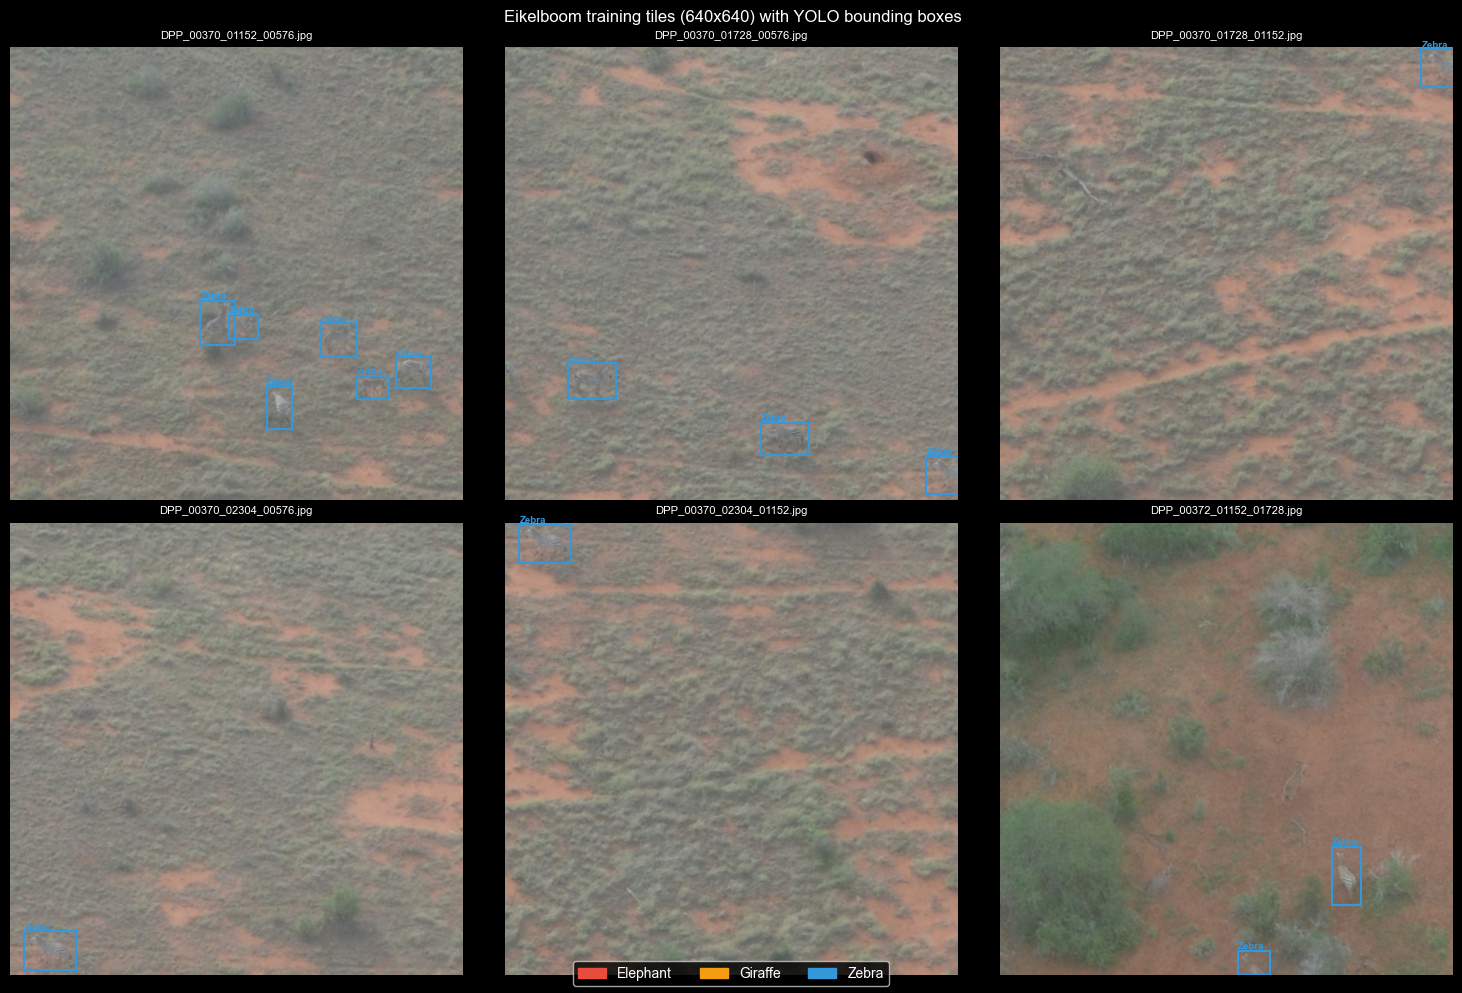

In [4]:
# Visualize a few training tiles with their YOLO labels
# Pick tiles that have annotations
annotated_tiles = [p for p in train_imgs if (TILED_DIR / "labels" / "train" / (p.stem + ".txt")).exists()
                   and (TILED_DIR / "labels" / "train" / (p.stem + ".txt")).stat().st_size > 0]
sample_tiles = annotated_tiles[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, tile_path in zip(axes.flat, sample_tiles):
    img = np.array(Image.open(tile_path))
    h, w = img.shape[:2]
    ax.imshow(img)

    label_path = TILED_DIR / "labels" / "train" / (tile_path.stem + ".txt")
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = [float(x) for x in parts[1:]]
            # Convert normalized xywh to pixel coords
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            box_w = bw * w
            box_h = bh * h
            color = CLASS_COLORS.get(cls_id, "white")
            ax.add_patch(mpatches.Rectangle(
                (x1, y1), box_w, box_h,
                linewidth=1.5, edgecolor=color, facecolor="none",
            ))
            ax.text(x1, y1 - 2, CLASS_NAMES.get(cls_id, str(cls_id)),
                    fontsize=7, color=color, fontweight="bold")

    ax.set_title(tile_path.name, fontsize=8)
    ax.axis("off")

legend_patches = [mpatches.Patch(color=c, label=n) for n, c in zip(CLASS_NAMES.values(), CLASS_COLORS.values())]
fig.legend(handles=legend_patches, loc="lower center", ncol=3)
plt.suptitle("Eikelboom training tiles (640x640) with YOLO bounding boxes", fontsize=12)
plt.tight_layout()

---

# Part A — YOLO Training

## 2 — Train YOLOv8 on the Eikelboom tiles

YOLOv8 training is a single function call via the `ultralytics` API.
We start from `yolov8n.pt` (nano, 3.2M params) — the smallest model,
which trains fast and is enough for a demo.

The `dataset.yaml` tells YOLO where to find images, labels, and class names.

In [ ]:
from ultralytics import YOLO

YOLO_EPOCHS = 10  # Increase to 50-100 for real training

yolo_model = YOLO("yolov8n.pt")  # pre-trained COCO nano model

results = yolo_model.train(
    data=str(TILED_DIR / "dataset.yaml"),
    epochs=YOLO_EPOCHS,
    imgsz=640,
    batch=16,
    device=DEVICE,
    project=str(DATA_DIR / "yolo_runs"),
    name="eikelboom_yolov8n",
    exist_ok=True,
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.4.28 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.27 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/eikelboom_tiled/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=eikelboom_yolov8n, nbs=64, 

/Users/christian/opt/anaconda3/envs/fit-training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting labels to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/runs/data/yolo_runs/eikelboom_yolov8n/labels.jpg... 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/runs/data/yolo_runs/eikelboom_yolov8n
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      4.27G      1.879      3.785      1.359         44        640: 93% ━━━━━━━━━━━─ 62/67 2.8s/it 2:40<13.9ss


## 3 — Evaluate YOLO on validation tiles

In [ ]:
# Validate and print metrics
val_results = yolo_model.val(
    data=str(TILED_DIR / "dataset.yaml"),
    device=DEVICE,
)

print(f"\nValidation metrics after {YOLO_EPOCHS} epochs:")
print(f"  mAP@50      : {val_results.box.map50:.3f}")
print(f"  mAP@50-95   : {val_results.box.map:.3f}")
print(f"  Precision   : {val_results.box.mp:.3f}")
print(f"  Recall      : {val_results.box.mr:.3f}")

In [ ]:
# Visualize predictions on validation tiles
sample_val = [str(p) for p in val_imgs[:6]]
preds = yolo_model.predict(sample_val, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, pred, img_path in zip(axes.flat, preds, sample_val):
    annotated = pred.plot()[:, :, ::-1]  # BGR -> RGB
    ax.imshow(annotated)
    ax.set_title(Path(img_path).name, fontsize=8)
    ax.axis("off")

plt.suptitle(f"YOLOv8n predictions after {YOLO_EPOCHS} epochs", fontsize=12)
plt.tight_layout()

## 4 — Inspect training curves

Ultralytics saves training metrics as a CSV. Let's plot the loss and mAP curves.

In [ ]:
results_csv = DATA_DIR / "yolo_runs" / "eikelboom_yolov8n" / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.plot(df["epoch"], df["train/box_loss"], label="train box_loss")
    ax.plot(df["epoch"], df["val/box_loss"], label="val box_loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Box Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(df["epoch"], df["train/cls_loss"], label="train cls_loss")
    ax.plot(df["epoch"], df["val/cls_loss"], label="val cls_loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Classification Loss")
    ax.legend()

    ax = axes[2]
    if "metrics/mAP50(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50")
        ax.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.set_title("Validation mAP")
    ax.legend()
    ax.set_ylim(0, 1)

    plt.suptitle("YOLOv8n training curves", fontsize=12)
    plt.tight_layout()
else:
    print(f"Results CSV not found at {results_csv}")

---

# Part B — HerdNet (Point-Based Detection) Training

## 5 — Prepare point annotations from COCO bounding boxes

HerdNet uses **point annotations** — the center of each bounding box.
This is cheaper to annotate (one click vs. drawing a box) and works well
for dense aerial scenes where boxes overlap heavily.

We convert the COCO bounding boxes to center points.

In [ ]:
def coco_to_points(coco_json_path):
    """Convert COCO bounding box annotations to center-point annotations."""
    with open(coco_json_path) as f:
        coco = json.load(f)

    img_lookup = {img["id"]: img["file_name"] for img in coco["images"]}

    rows = []
    for ann in coco["annotations"]:
        x, y, w, h = ann["bbox"]  # COCO: [x, y, w, h] top-left
        cx = x + w / 2
        cy = y + h / 2
        rows.append({
            "tile_filename": img_lookup[ann["image_id"]],
            "local_x": cx,
            "local_y": cy,
            "class_label": ann["category_id"],
        })

    return pd.DataFrame(rows)


train_points = coco_to_points(COCO_DIR / "train" / "annotations.json")
val_points = coco_to_points(COCO_DIR / "val" / "annotations.json")

all_points = pd.concat([train_points, val_points], ignore_index=True)

print(f"Train points: {len(train_points)} across {train_points['tile_filename'].nunique()} tiles")
print(f"Val points:   {len(val_points)} across {val_points['tile_filename'].nunique()} tiles")
print(f"\nSample:")
train_points.head()

In [ ]:
# Visualize tiles with point annotations
# Pick tiles with many points
top_tiles = train_points.groupby("tile_filename").size().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, fname in zip(axes.flat, top_tiles):
    img = np.array(Image.open(TILED_DIR / "images" / "train" / fname))
    ax.imshow(img)

    tile_pts = train_points[train_points["tile_filename"] == fname]
    ax.scatter(tile_pts["local_x"], tile_pts["local_y"],
              c="#E74C3C", s=40, marker="+", linewidths=1.5)

    ax.set_title(f"{fname} ({len(tile_pts)} points)", fontsize=8)
    ax.axis("off")

plt.suptitle("Training tiles with point annotations (box centers)", fontsize=12)
plt.tight_layout()

## 6 — Build the HerdNet dataset and model

HerdNet converts point annotations into **FIDT (Focal Inverse Distance Transform)**
density maps. The model learns to predict these maps — each peak corresponds
to one animal.

We use the simplified HerdNet from `wildlife_detection.training.herdnet`:
ResNet-34 encoder → Conv decoder → sigmoid density map.

In [ ]:
from wildlife_detection.training.datasets import HerdNetDataset
from wildlife_detection.training.herdnet import build_simple_herdnet, evaluate_herdnet

PATCH_SIZE = 640
DOWN_RATIO = 2
FIDT_RADIUS = 1
BATCH_SIZE = 8

train_files = train_points["tile_filename"].unique().tolist()
val_files = val_points["tile_filename"].unique().tolist()

train_ds = HerdNetDataset(
    TILED_DIR / "images" / "train", all_points, train_files,
    patch_size=PATCH_SIZE, down_ratio=DOWN_RATIO,
    fidt_radius=FIDT_RADIUS, augment=True,
)
val_ds = HerdNetDataset(
    TILED_DIR / "images" / "val", all_points, val_files,
    patch_size=PATCH_SIZE, down_ratio=DOWN_RATIO,
    fidt_radius=FIDT_RADIUS, augment=False,
)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train dataset: {len(train_ds)} tiles")
print(f"Val dataset:   {len(val_ds)} tiles")

# Inspect one sample
sample_img, sample_fidt, sample_count = train_ds[0]
print(f"\nSample shapes:")
print(f"  Image tensor : {sample_img.shape}")
print(f"  FIDT map     : {sample_fidt.shape}  (downsampled by {DOWN_RATIO}x)")
print(f"  Point count  : {sample_count}")

In [ ]:
# Visualize the FIDT density map vs. the input image
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Denormalize image for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
display_img = (sample_img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

axes[0].imshow(display_img)
axes[0].set_title(f"Input tile ({sample_count} animals)")

axes[1].imshow(sample_fidt[0].numpy(), cmap="hot", vmin=0, vmax=1)
axes[1].set_title(f"FIDT density map ({sample_fidt.shape[1]}x{sample_fidt.shape[2]} px)")

# Overlay
axes[2].imshow(display_img)
fidt_resized = torch.nn.functional.interpolate(
    sample_fidt.unsqueeze(0), size=display_img.shape[:2], mode="bilinear"
)[0, 0].numpy()
axes[2].imshow(fidt_resized, cmap="hot", alpha=0.5, vmin=0, vmax=1)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")
plt.suptitle("HerdNet training target: FIDT density map from point annotations", fontsize=12)
plt.tight_layout()

## 7 — Train the simplified HerdNet

In [ ]:
HERDNET_EPOCHS = 10  # Increase to 30-50 for real training
LR = 1e-3

device = torch.device(DEVICE)
model = build_simple_herdnet(num_classes=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, min_lr=1e-6)
criterion = torch.nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: simplified HerdNet (ResNet-34 encoder + Conv decoder)")
print(f"Trainable parameters: {n_params:,}")
print(f"Training for {HERDNET_EPOCHS} epochs on {DEVICE}...\n")

history = {"epoch": [], "train_loss": [], "val_loss": [],
           "precision": [], "recall": [], "f1": [], "mae": []}

for epoch in range(HERDNET_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    for imgs, fidt_maps, counts in train_loader:
        imgs, fidt_maps = imgs.to(device), fidt_maps.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        if preds.shape[-2:] != fidt_maps.shape[-2:]:
            preds = torch.nn.functional.interpolate(
                preds, size=fidt_maps.shape[-2:], mode="bilinear", align_corners=False,
            )
        loss = criterion(preds, fidt_maps)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, fidt_maps, counts in val_loader:
            imgs, fidt_maps = imgs.to(device), fidt_maps.to(device)
            preds = model(imgs)
            if preds.shape[-2:] != fidt_maps.shape[-2:]:
                preds = torch.nn.functional.interpolate(
                    preds, size=fidt_maps.shape[-2:], mode="bilinear", align_corners=False,
                )
            val_loss += criterion(preds, fidt_maps).item()
    val_loss /= len(val_loader)

    p, r, f1, mae = evaluate_herdnet(model, val_loader, device)
    scheduler.step(val_loss)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["precision"].append(p)
    history["recall"].append(r)
    history["f1"].append(f1)
    history["mae"].append(mae)

    print(f"Epoch {epoch+1:>2d}/{HERDNET_EPOCHS} — "
          f"train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
          f"F1: {f1:.3f}, MAE: {mae:.2f}")

print(f"\nTraining complete.")

## 8 — HerdNet training curves

In [ ]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(hist["epoch"], hist["train_loss"], label="train")
ax.plot(hist["epoch"], hist["val_loss"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Loss")
ax.legend()

ax = axes[1]
ax.plot(hist["epoch"], hist["precision"], label="Precision")
ax.plot(hist["epoch"], hist["recall"], label="Recall")
ax.plot(hist["epoch"], hist["f1"], label="F1", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Detection metrics")
ax.legend()
ax.set_ylim(0, 1)

ax = axes[2]
ax.plot(hist["epoch"], hist["mae"], color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.set_title("Count error (MAE)")

plt.suptitle("HerdNet training curves", fontsize=12)
plt.tight_layout()

## 9 — Visualize HerdNet predictions

In [ ]:
model.eval()
sample_imgs, sample_fidts, sample_counts = next(iter(val_loader))
sample_imgs_gpu = sample_imgs.to(device)

with torch.no_grad():
    sample_preds = model(sample_imgs_gpu)
    if sample_preds.shape[-2:] != sample_fidts.shape[-2:]:
        sample_preds = torch.nn.functional.interpolate(
            sample_preds, size=sample_fidts.shape[-2:], mode="bilinear", align_corners=False,
        )

n_show = min(4, len(sample_imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show))

for i in range(n_show):
    # Denormalize
    display = (sample_imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    gt_map = sample_fidts[i, 0].numpy()
    pred_map = sample_preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(display)
    axes[i, 0].set_title(f"Input (count={sample_counts[i].item()})")

    axes[i, 1].imshow(gt_map, cmap="hot", vmin=0, vmax=1)
    axes[i, 1].set_title("Ground truth FIDT")

    axes[i, 2].imshow(pred_map, cmap="hot", vmin=0, vmax=max(0.1, pred_map.max()))
    axes[i, 2].set_title("Predicted heatmap")

    for ax in axes[i]:
        ax.axis("off")

plt.suptitle(f"HerdNet predictions after {HERDNET_EPOCHS} epochs", fontsize=12)
plt.tight_layout()

---

## Exercises

### YOLO

1. **More epochs** — Increase `YOLO_EPOCHS` to 50 or 100. How much does mAP improve?
   At what point do the training curves flatten?

2. **Model size** — Try `yolov8s.pt` (small, 11M params) or `yolov8m.pt` (medium, 25M params).
   How does model size affect mAP and training speed?

3. **Augmentation** — Ultralytics applies augmentation by default (mosaic, flip, hsv).
   Try `augment=False` in `yolo_model.train()`. How much does augmentation help?

### HerdNet

4. **FIDT radius** — Change `FIDT_RADIUS` from 1 to 3 or 5. How does the density
   map change? Does a larger radius make training easier or harder?

5. **Threshold sensitivity** — The evaluate function uses a threshold of 0.3 for peak
   detection. Try 0.1, 0.3, 0.5. Which gives the best F1?

### Comparison

6. **Boxes vs. points** — Compare the YOLO and HerdNet outputs on the same tiles.
   YOLO gives you species labels + bounding boxes. HerdNet gives you counts.
   When would you prefer one over the other for ecological surveys?

## Reflection

- Training YOLOv8 on 1000 tiles for 10 epochs takes minutes. How does this compare
  to the effort of manually annotating the training data?

- HerdNet uses point annotations (one click per animal) while YOLO needs bounding
  boxes (two clicks + adjustment). For a new aerial survey with 10,000 images,
  how would annotation cost differ between the two approaches?

- The simplified HerdNet here uses a ResNet-34 backbone. The full HerdNet uses
  Deep Layer Aggregation (DLA). What are the trade-offs of a more complex backbone?

- Both models trained on 640x640 tiles. How would you handle inference on a full
  4603x3068 aerial image? (Hint: think about SAHI for YOLO, and the HerdNet Stitcher
  from practical_06.)